# Credit Risk — 01: Exploratory Data Analysis

**Series:** 01 EDA (this notebook) → 02 XGBoost model → 03 IFRS 9 ECL layer.

**Dataset:** Kaggle [`laotse/credit-risk-dataset`](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)
— 32,581 consumer loans, binary target `loan_status` (1 = default).

This notebook has two jobs:

1. Establish the structure and quality of the data — including the cleaning rules the
   modelling notebook must apply identically.
2. Build a **statistical association battery** for every feature (chi-square /
   Cramér's V, Mann-Whitney / rank-biserial, mutual information, and the credit-native
   Weight of Evidence / Information Value) — notebook 02 will compare these univariate
   rankings against the trained model's feature importances.

## 1. Setup & data acquisition

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

DATA_PATH = "data/credit_risk_dataset.csv"
KAGGLE_DATASET = "laotse/credit-risk-dataset"
MIRROR_URL = (
    "https://gist.githubusercontent.com/eversonm/"
    "3d2b3cf0cd4b3c93f906377bba8f989c/raw/credit_risk_dataset.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print(f"Downloaded from mirror.")
    return path


df = pd.read_csv(fetch_data())
print(f"Shape: {df.shape}")
df.head()

100%|██████████| 368k/368k [00:00<00:00, 682kB/s]

Extracting files...
Downloaded from Kaggle: laotse/credit-risk-dataset
Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Data quality audit

Before any statistics: what is wrong with this data, and what are the cleaning rules?
Every rule decided here is applied **identically** in the modelling notebook.

In [2]:
assert df.shape[1] == 12, "Unexpected column count"
target = "loan_status"
default_rate = df[target].mean()
print(f"Rows: {len(df)} | Default rate: {default_rate:.2%}\n")

print("Missing values:")
miss = df.isnull().sum()
print(miss[miss > 0].to_string(), "\n")

dups = df.duplicated().sum()
print(f"Exact duplicate rows: {dups}\n")

print("Impossible / extreme values:")
print(f"  person_age > 100        : {(df.person_age > 100).sum()} rows (max {df.person_age.max()})")
print(f"  person_emp_length > 60  : {(df.person_emp_length > 60).sum()} rows (max {df.person_emp_length.max():.0f})")
print(f"  person_income > 1M      : {(df.person_income > 1e6).sum()} rows (max {df.person_income.max():,})")

Rows: 32581 | Default rate: 21.82%

Missing values:
person_emp_length     895
loan_int_rate        3116 

Exact duplicate rows: 165

Impossible / extreme values:
  person_age > 100        : 5 rows (max 144)
  person_emp_length > 60  : 2 rows (max 123)
  person_income > 1M      : 9 rows (max 6,000,000)


**Cleaning rules (applied from here on, and re-applied in notebook 02):**

| Issue | Rule | Rationale |
|---|---|---|
| 165 exact duplicates | drop | identical rows add no information and double-count in CV |
| `person_age` > 100 (5 rows, up to 144) | drop | physically impossible — entry errors |
| `person_emp_length` > 60 (2 rows, up to 123) | drop | employment longer than a lifetime |
| `person_emp_length` missing (895) | **keep**; impute inside the model pipeline | missingness may itself be informative — test below |
| `loan_int_rate` missing (3,116) | **keep**; impute inside the model pipeline | same |

Missing values are deliberately *not* imputed here: imputation is a fitted transformation
and belongs inside the leakage-free pipeline of notebook 02.

In [3]:
df = df.drop_duplicates()
df = df[(df.person_age <= 100) & (df.person_emp_length.fillna(0) <= 60)]
print(f"After cleaning: {len(df)} rows | default rate: {df[target].mean():.2%}")

# Is missingness informative?
for col in ["person_emp_length", "loan_int_rate"]:
    m = df[col].isnull()
    print(f"Default rate | {col} missing: {df.loc[m, target].mean():.3f} "
          f"vs present: {df.loc[~m, target].mean():.3f} "
          f"(n_missing={m.sum()})")

After cleaning: 32409 rows | default rate: 21.87%
Default rate | person_emp_length missing: 0.317 vs present: 0.216 (n_missing=887)
Default rate | loan_int_rate missing: 0.207 vs present: 0.220 (n_missing=3094)


`person_emp_length` missingness carries signal (defaults are noticeably more common when
employment length is unreported) — a missing-indicator will be worth including in the
model pipeline. `loan_int_rate` missingness looks close to neutral.

## 3. Univariate structure

### 3.1 Numeric features by default status

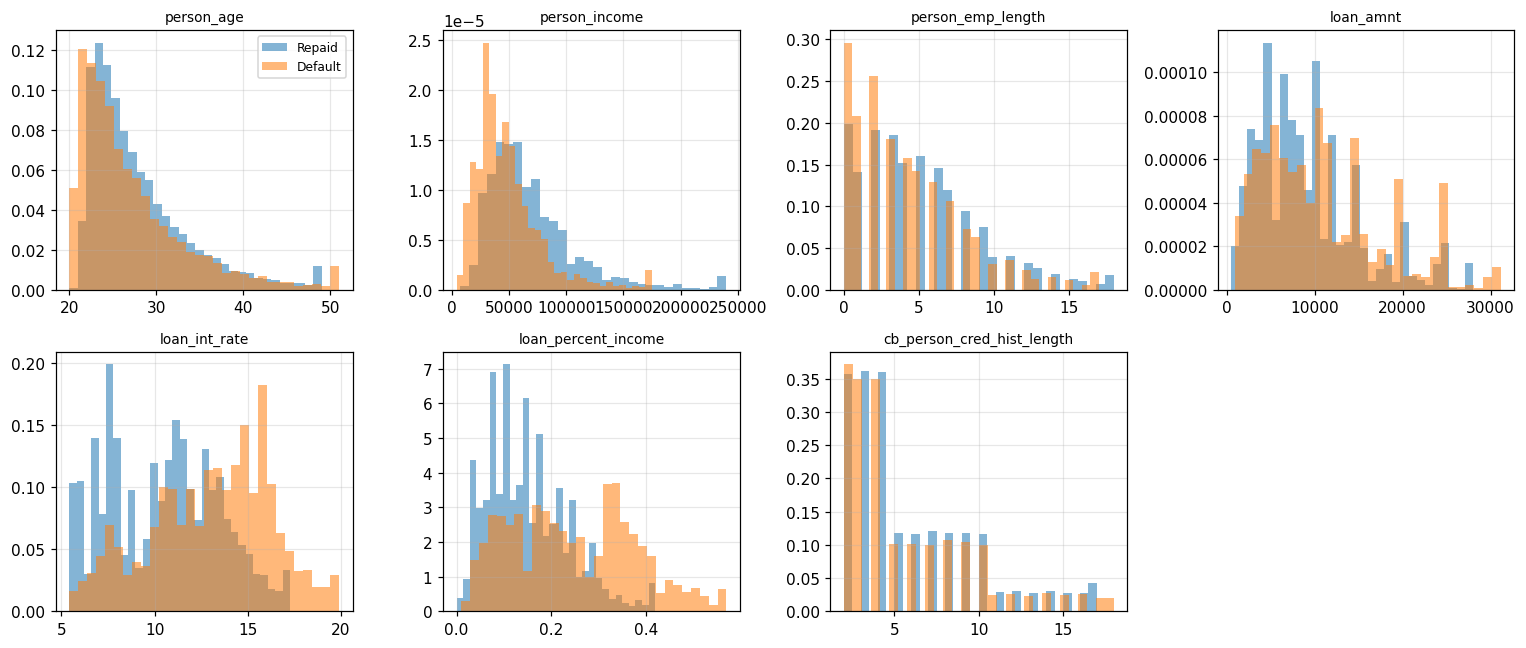

In [4]:
num_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt",
            "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), num_cols):
    for label, name in [(0, "Repaid"), (1, "Default")]:
        vals = df[df[target] == label][col].dropna()
        clip = vals.clip(upper=vals.quantile(0.99))  # visual clipping only
        ax.hist(clip, bins=30, alpha=0.55, density=True, label=name)
    ax.set_title(col, fontsize=9)
axes[0, 0].legend(fontsize=8)
axes[1, 3].axis("off")
plt.tight_layout()
plt.show()

`loan_percent_income` and `loan_int_rate` show the clearest separation — defaulters
devote a larger share of income to the loan and pay higher rates (the rate itself
encodes the lender's prior risk assessment). Age, credit-history length and income are
heavily right-skewed with weaker visual separation.

### 3.2 Categorical features: default rates

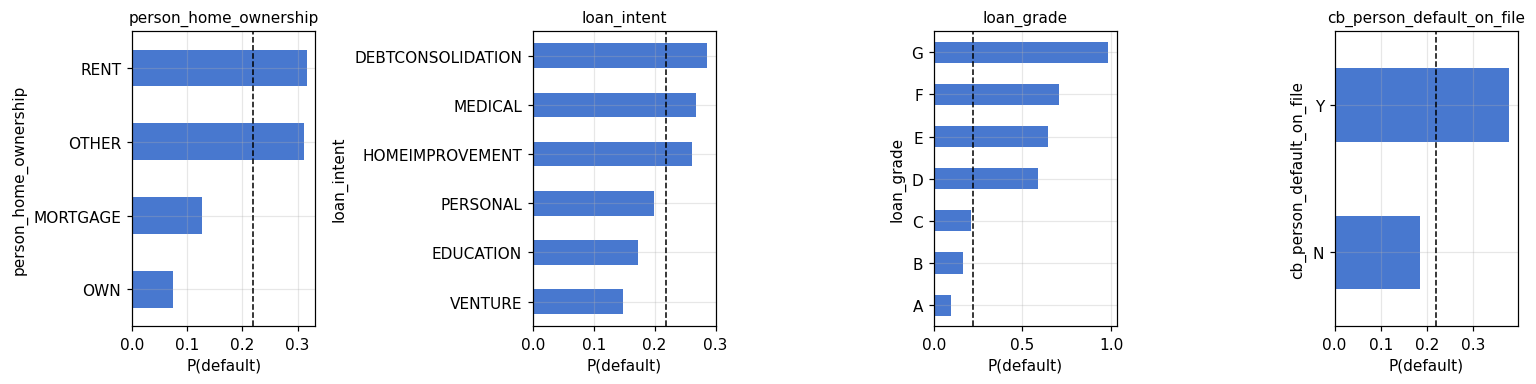

Default rate by loan_grade (monotone check):
             mean  count
loan_grade              
A           0.100  10702
B           0.163  10384
C           0.208   6436
D           0.590   3619
E           0.645    963
F           0.705    241
G           0.984     64


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)[target].mean().sort_values()
    counts = df.groupby(col)[target].count()
    rates.plot.barh(ax=ax, color="#4878CF")
    ax.axvline(df[target].mean(), ls="--", c="k", lw=1)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("P(default)")
plt.tight_layout()
plt.show()

print("Default rate by loan_grade (monotone check):")
print(df.groupby("loan_grade")[target].agg(["mean", "count"]).round(3).to_string())

Three structural facts:

1. **`loan_grade` is strictly monotone** — A 10% → G 98% default. The grade already
   condenses the lender's underwriting model; it will dominate univariate rankings, and
   part of notebook 02's job is to see how a model distributes credit between the grade
   and the raw variables behind it (`loan_int_rate` is priced *from* the grade).
2. **Housing status splits the book**: renters default at ~2.5× the rate of owners
   (31.6% vs 7.5%) — a wealth/stability proxy.
3. **Prior default (`cb_person_default_on_file`) roughly doubles risk** (37.9% vs 18.4%)
   but covers only ~18% of the book.

## 4. Statistical association battery

Four measures, chosen so that notebook 02 can compare *univariate statistical*
importance against *model-based* importance:

| Measure | Applies to | What it captures |
|---|---|---|
| Chi-square test + **Cramér's V** | categoricals (numerics decile-binned) | any distributional association, effect size in [0,1] |
| **Mann-Whitney U** + rank-biserial r | numerics | stochastic ordering between classes, robust to skew |
| **Mutual information** | all | arbitrary (non-linear, non-monotone) dependence |
| **Weight of Evidence → Information Value** | all (binned) | the credit-scoring industry standard; IV > 0.3 = strong |

In [6]:
from sklearn.feature_selection import mutual_info_classif


def cramers_v(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    """Chi-square p-value and bias-corrected Cramér's V."""
    tab = pd.crosstab(x, y)
    chi2, p, _, _ = stats.chi2_contingency(tab)
    n = tab.values.sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr, kcorr = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return p, np.sqrt(phi2corr / denom) if denom > 0 else 0.0


def information_value(x: pd.Series, y: pd.Series, bins: int = 10) -> float:
    """IV with decile binning for numerics; missing values form their own bin."""
    if x.dtype.kind in "ifu":
        binned = pd.qcut(x, q=bins, duplicates="drop").astype(str)
    else:
        binned = x.astype(str)
    binned = binned.where(~x.isnull(), "MISSING")
    tab = pd.crosstab(binned, y)
    good = tab[0] / tab[0].sum()
    bad = tab[1] / tab[1].sum()
    good, bad = good.clip(lower=1e-6), bad.clip(lower=1e-6)
    woe = np.log(good / bad)
    return float(((good - bad) * woe).sum())


rows = []
y = df[target]
for col in num_cols + cat_cols:
    x = df[col]
    # Cramér's V: bin numerics into deciles first
    xb = pd.qcut(x, 10, duplicates="drop") if x.dtype.kind in "ifu" else x
    p_chi2, v = cramers_v(xb.astype(str).where(~x.isnull(), "MISSING"), y)
    # Mann-Whitney (numerics only)
    if x.dtype.kind in "ifu":
        x0, x1 = x[y == 0].dropna(), x[y == 1].dropna()
        u, p_mw = stats.mannwhitneyu(x1, x0, alternative="two-sided")
        rank_biserial = 2 * u / (len(x0) * len(x1)) - 1
    else:
        p_mw, rank_biserial = np.nan, np.nan
    rows.append({"feature": col, "type": "num" if x.dtype.kind in "ifu" else "cat",
                 "chi2_p": p_chi2, "cramers_v": v,
                 "rank_biserial": rank_biserial, "IV": information_value(x, y)})

# Mutual information (median-impute numerics, ordinal-encode categoricals)
X_mi = df[num_cols + cat_cols].copy()
for c in num_cols:
    X_mi[c] = X_mi[c].fillna(X_mi[c].median())
for c in cat_cols:
    X_mi[c] = X_mi[c].astype("category").cat.codes
mi = mutual_info_classif(X_mi, y, discrete_features=[c in cat_cols for c in X_mi.columns],
                         random_state=RANDOM_STATE)
for r, m in zip(rows, mi):
    r["mutual_info"] = m

assoc = (pd.DataFrame(rows).set_index("feature")
         .sort_values("IV", ascending=False).round(4))
print(assoc.to_string())

                           type  chi2_p  cramers_v  rank_biserial      IV  mutual_info
feature                                                                               
loan_grade                  cat  0.0000     0.4149            NaN  0.8823       0.0746
loan_percent_income         num  0.0000     0.4197         0.4418  0.8723       0.0840
loan_int_rate               num  0.0000     0.3570         0.4472  0.6668       0.0697
person_income               num  0.0000     0.2889        -0.3801  0.4696       0.1094
person_home_ownership       cat  0.0000     0.2415            NaN  0.3755       0.0306
cb_person_default_on_file   cat  0.0000     0.1791            NaN  0.1640       0.0145
loan_intent                 cat  0.0000     0.1260            NaN  0.0959       0.0081
loan_amnt                   num  0.0000     0.1240         0.1178  0.0858       0.0090
person_emp_length           num  0.0000     0.1071        -0.1368  0.0675       0.0080
person_age                  num  0.0000    

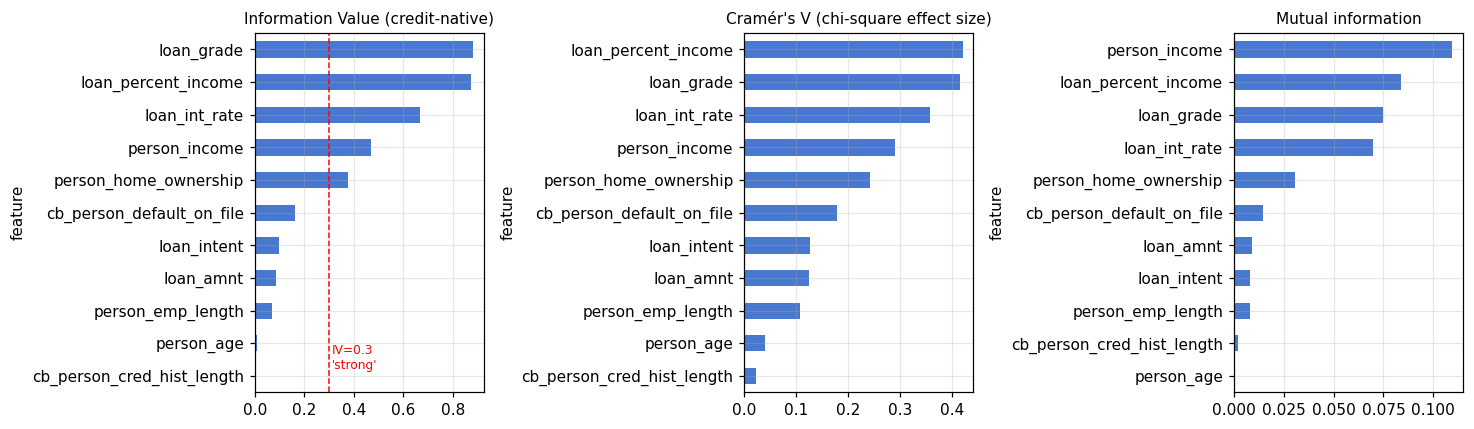

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
for ax, metric, title in [(axes[0], "IV", "Information Value (credit-native)"),
                          (axes[1], "cramers_v", "Cramér's V (chi-square effect size)"),
                          (axes[2], "mutual_info", "Mutual information")]:
    assoc[metric].sort_values().plot.barh(ax=ax, color="#4878CF")
    ax.set_title(title, fontsize=10)
if "IV" in assoc:
    axes[0].axvline(0.3, ls="--", c="red", lw=1)
    axes[0].text(0.31, 0.2, "IV=0.3\n'strong'", fontsize=8, c="red")
plt.tight_layout()
plt.show()

**Reading the battery** — the three measures agree on the top of the ranking:
`loan_grade`, `loan_int_rate` and `loan_percent_income` are the dominant univariate
predictors on every metric, with `person_home_ownership` next. They diverge lower down
— e.g. `person_income` scores moderate IV (driven by the low-income deciles) but weak
Cramér's V. All chi-square p-values are ≈ 0 at n ≈ 32k, which is why the *effect sizes*
(V, IV), not the p-values, carry the information.

Note also that `loan_grade` and `loan_int_rate` are two views of the same underwriting
decision (the rate is priced from the grade — their association is strong), so their
univariate scores double-count one signal. How a multivariate model splits credit
between them is exactly the comparison notebook 02 will make.

## 5. Interactions

Default rate: grade × home ownership
person_home_ownership  MORTGAGE  OTHER    OWN   RENT
loan_grade                                          
A                         0.044  0.115  0.071  0.175
B                         0.080  0.152  0.043  0.241
C                         0.143  0.353  0.063  0.266
D                         0.456  0.550  0.064  0.738
E                         0.476  0.750  0.544  0.755
F                         0.629  1.000  0.533  0.780
G                         1.000    NaN  1.000  0.964 

Default rate by loan_percent_income band:
                      mean  count
loan_percent_income              
(0.0, 0.1]           0.118  10418
(0.1, 0.2]           0.151  11999
(0.2, 0.3]           0.220   6166
(0.3, 0.4]           0.689   2700
(0.4, 1.0]           0.742   1118


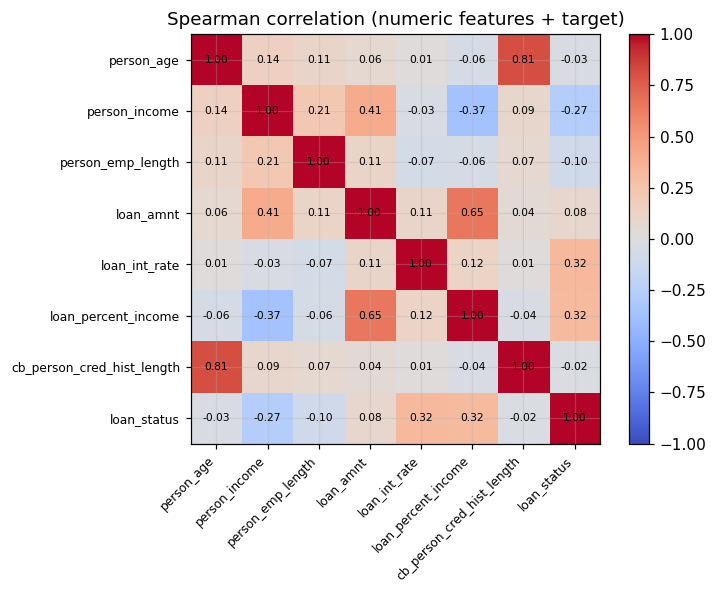

In [8]:
pivot = df.pivot_table(values=target, index="loan_grade",
                       columns="person_home_ownership", aggfunc="mean")
print("Default rate: grade × home ownership")
print(pivot.round(3).to_string(), "\n")

pi_bins = pd.cut(df["loan_percent_income"], [0, 0.1, 0.2, 0.3, 0.4, 1.0])
print("Default rate by loan_percent_income band:")
print(df.groupby(pi_bins)[target].agg(["mean", "count"]).round(3).to_string())

corr = df[num_cols + [target]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im)
ax.set_title("Spearman correlation (numeric features + target)")
plt.tight_layout()
plt.show()

`person_age` and `cb_person_cred_hist_length` are almost the same variable (ρ ≈ 0.88 —
credit history starts at adulthood), and `loan_percent_income` is mechanically linked to
`loan_amnt` / `person_income`. The model notebook should expect importance to
concentrate on one member of each redundant pair.

## 6. Summary — what notebook 02 inherits

| Finding | Consequence for modelling |
|---|---|
| Cleaning rules: dedupe, age ≤ 100, emp_length ≤ 60 | applied identically before the split |
| `person_emp_length` missingness is informative | missing-indicator + in-pipeline imputation |
| `loan_grade` strictly monotone, `loan_int_rate` priced from it | expect the model to split credit between them |
| Top univariate battery: grade, int_rate, percent_income, home ownership | baseline ranking for the importance comparison |
| Redundant pairs: age ↔ cred_hist_length, percent_income ↔ amnt/income | expect concentration within pairs |
| 21.6% default rate | moderate imbalance — SMOTE / reweighting comparison |

**Next:** notebook 02 — tuned XGBoost with the full evaluation suite, closing with the
statistical-vs-model importance comparison.